## Training Pipeline (IsolationForest + SHAP Explainability)



In [92]:
import json
from pathlib import Path

from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def print_section(title):
    print("=" * 50)
    print(title)
    print("=" * 50)


def format_number(value):
    if pd.isna(value):
        return "missing"
    if isinstance(value, (int, np.integer)):
        return f"{int(value):,}"
    if isinstance(value, (float, np.floating)):
        return f"{value:,.4f}".rstrip("0").rstrip(".")
    return str(value)


def assign_severity(scores, medium_cutoff, anomaly_threshold):
    return np.select(
        [
            scores >= anomaly_threshold,
            scores >= medium_cutoff,
        ],
        ["high", "medium"],
        default="low",
    )


def to_builtin(value):
    if isinstance(value, dict):
        return {str(k): to_builtin(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_builtin(v) for v in value]
    if isinstance(value, tuple):
        return [to_builtin(v) for v in value]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    return value


print("Libraries loaded successfully.")
print(f"SHAP version: {shap.__version__}")

Libraries loaded successfully.
SHAP version: 0.51.0


## 1. Load & Feature Engineering

In [93]:
data = pd.read_csv("../data/csv/JakartaOCDSFinalData.csv", parse_dates=["date", "award_date"])
data = data.sort_values("award_date").reset_index(drop=True)

# Feature engineering
data["award_month"]           = data["award_date"].dt.month
data["award_quarter"]         = data["award_date"].dt.quarter
data["award_weekday"]         = data["award_date"].dt.weekday
data["log_tender_minvalue"]   = np.log1p(data["tender_minvalue"])
data["log_award_value"]       = np.log1p(data["award_value"])
data["value_gap"]             = data["award_value"] - data["tender_minvalue"]
data["title_word_count"]      = data["tender_title"].fillna("").str.split().str.len()
data["award_title_word_count"]= data["award_title"].fillna("").str.split().str.len()
data["supplier_count"]        = data["award_supplier"].fillna("").astype(str).str.split(",").str.len()
data["award_value_per_day"]   = data["award_value"] / data["days_to_award"].replace(0, 1)
data["same_day_award_flag"]   = (data["days_to_award"] == 0).astype(int)

model_numeric_features = [
    "tender_minvalue",
    "award_value",
    "days_to_award",
    "budget_utilization_ratio",
    "value_gap",
    "log_tender_minvalue",
    "log_award_value",
    "title_word_count",
    "award_title_word_count",
    "supplier_count",
    "award_value_per_day",
    "same_day_award_flag",
    "award_month",
    "award_quarter",
    "award_weekday",
]

model_categorical_features = ["mainprocurementcategory"]

# Fitur yang dipakai untuk local explanation (subset yang paling interpretable)
explanation_numeric_features = [
    "tender_minvalue",
    "award_value",
    "days_to_award",
    "budget_utilization_ratio",
    "value_gap",
    "supplier_count",
    "title_word_count",
    "award_value_per_day",
]

excluded_from_model = {
    "buyer_name": "Excluded: heavily imbalanced, adds weak signal.",
    "tender_status": "Excluded: effectively constant in the cleaned dataset.",
}

print_section("POST-AWARD DATASET")
print(f"Rows            : {len(data)}")
print(f"Columns         : {len(data.columns)}")
print(f"Award date span : {data['award_date'].min().date()} -> {data['award_date'].max().date()}")
print(f"Suppliers       : {data['award_supplier'].nunique()}")
print(f"Categories      : {data['mainprocurementcategory'].nunique()}")
print("\nModel features  :", model_numeric_features + model_categorical_features)
display(data[["award_date", "buyer_name", "mainprocurementcategory",
              "tender_minvalue", "award_value", "days_to_award",
              "budget_utilization_ratio"]].head(5))

POST-AWARD DATASET
Rows            : 8678
Columns         : 23
Award date span : 2014-12-24 -> 2023-10-18
Suppliers       : 2710
Categories      : 3

Model features  : ['tender_minvalue', 'award_value', 'days_to_award', 'budget_utilization_ratio', 'value_gap', 'log_tender_minvalue', 'log_award_value', 'title_word_count', 'award_title_word_count', 'supplier_count', 'award_value_per_day', 'same_day_award_flag', 'award_month', 'award_quarter', 'award_weekday', 'mainprocurementcategory']


,award_date,buyer_name,mainprocurementcategory,tender_minvalue,award_value,days_to_award,budget_utilization_ratio
0,2014-12-24,Pemerintah Daerah Provinsi Dki Jakarta,Goods,1.499502e+09,1.157888e+09,16,0.772182
1,2015-04-15,Pemerintah Daerah Provinsi Dki Jakarta,Services,1.988607e+10,1.934999e+10,15,0.973043
2,2015-04-17,Pemerintah Daerah Provinsi Dki Jakarta,Services,1.612680e+09,1.263166e+09,15,0.783271
3,2015-04-23,Pemerintah Daerah Provinsi Dki Jakarta,Goods,6.271924e+09,6.196783e+09,113,0.988019
4,2015-04-24,Pemerintah Daerah Provinsi Dki Jakarta,Goods,9.039069e+09,6.867945e+09,115,0.759807


## 2. Time-Based Split

In [94]:
artifact_dir = Path("artifacts/post_award_anomaly")
artifact_dir.mkdir(parents=True, exist_ok=True)

split_index   = int(len(data) * 0.85)
train_data    = data.iloc[:split_index].copy()
test_data     = data.iloc[split_index:].copy()

train_max_date = train_data["award_date"].max()
test_min_date  = test_data["award_date"].min()

print_section("TIME-BASED SPLIT")
print(f"Train rows      : {len(train_data)}")
print(f"Test rows       : {len(test_data)}")
print(f"Train max date  : {train_max_date.date()}")
print(f"Test min date   : {test_min_date.date()}")
print(f"Leakage check   : {train_max_date <= test_min_date}")

assert train_max_date <= test_min_date, "Temporal leakage detected!"

train_data.to_csv(artifact_dir / "train_post_award_split.csv", index=False)
test_data.to_csv(artifact_dir / "test_post_award_split.csv", index=False)
print("\nSplit files saved.")

TIME-BASED SPLIT
Train rows      : 7376
Test rows       : 1302
Train max date  : 2022-03-23
Test min date   : 2022-03-24
Leakage check   : True

Split files saved.


## 3. Preprocessing & IsolationForest Training

In [95]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            model_numeric_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", encoder),
            ]),
            model_categorical_features,
        ),
    ]
)

# Fit preprocessor HANYA pada train (leakage control)
X_train = preprocessor.fit_transform(
    train_data[model_numeric_features + model_categorical_features]
)
X_test = preprocessor.transform(
    test_data[model_numeric_features + model_categorical_features]
)

contamination = 0.03
model = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    random_state=42,
)
model.fit(X_train)

train_scores = -model.score_samples(X_train)
test_scores  = -model.score_samples(X_test)
medium_cutoff = float(np.quantile(train_scores, 0.70))
threshold     = float(np.quantile(train_scores, 1 - contamination))

train_data["anomaly_score"]    = train_scores
test_data["anomaly_score"]     = test_scores
train_data["prediction_label"] = np.where(train_scores >= threshold, "anomaly", "normal")
test_data["prediction_label"]  = np.where(test_scores >= threshold, "anomaly", "normal")
train_data["anomaly_flag"]     = (train_data["prediction_label"] == "anomaly").astype(int)
test_data["anomaly_flag"]      = (test_data["prediction_label"] == "anomaly").astype(int)
train_data["severity_band"]    = assign_severity(train_scores, medium_cutoff, threshold)
test_data["severity_band"]     = assign_severity(test_scores, medium_cutoff, threshold)

# Simpan artifacts
config = {
    "pipeline_type"            : "post_award_anomaly_detection",
    "explainability_method"    : "SHAP TreeExplainer (direct on IsolationForest)",
    "split_strategy"           : "time_based_85_15",
    "contamination"            : contamination,
    "medium_cutoff"            : medium_cutoff,
    "anomaly_threshold"        : threshold,
    "numeric_features"         : model_numeric_features,
    "categorical_features"     : model_categorical_features,
    "explanation_numeric_features": explanation_numeric_features,
    "excluded_from_model"      : excluded_from_model,
}
joblib.dump(model, artifact_dir / "isolation_forest.joblib")
joblib.dump(preprocessor, artifact_dir / "preprocessor.joblib")
(artifact_dir / "model_config.json").write_text(
    json.dumps(to_builtin(config), indent=2), encoding="utf-8"
)

print_section("MODEL RESULTS")
print(f"Medium score cutoff     : {medium_cutoff:.6f}")
print(f"Train anomaly threshold : {threshold:.6f}")
print(f"Train anomalies         : {train_data['anomaly_flag'].sum()} / {len(train_data)} ({train_data['anomaly_flag'].mean():.2%})")
print(f"Test anomalies          : {test_data['anomaly_flag'].sum()} / {len(test_data)} ({test_data['anomaly_flag'].mean():.2%})")
print("\nTest severity bands:")
print(test_data['severity_band'].value_counts().to_string())

MODEL RESULTS
Medium score cutoff     : 0.459542
Train anomaly threshold : 0.588172
Train anomalies         : 222 / 7376 (3.01%)
Test anomalies          : 36 / 1302 (2.76%)

Test severity bands:
severity_band
low       951
medium    315
high       36


## 4. SHAP Global Explainability 

SHAP GLOBAL EXPLAINABILITY
Menghitung SHAP values pada test set...
SHAP values shape: (1302, 18)

Top-10 Global SHAP Importance:
            raw_feature  mean_abs_shap
mainprocurementcategory       0.420356
          award_quarter       0.193393
              value_gap       0.168417
 award_title_word_count       0.164959
    award_value_per_day       0.162141
        tender_minvalue       0.161590
            award_month       0.148612
       title_word_count       0.147342
          days_to_award       0.141947
    log_tender_minvalue       0.136706


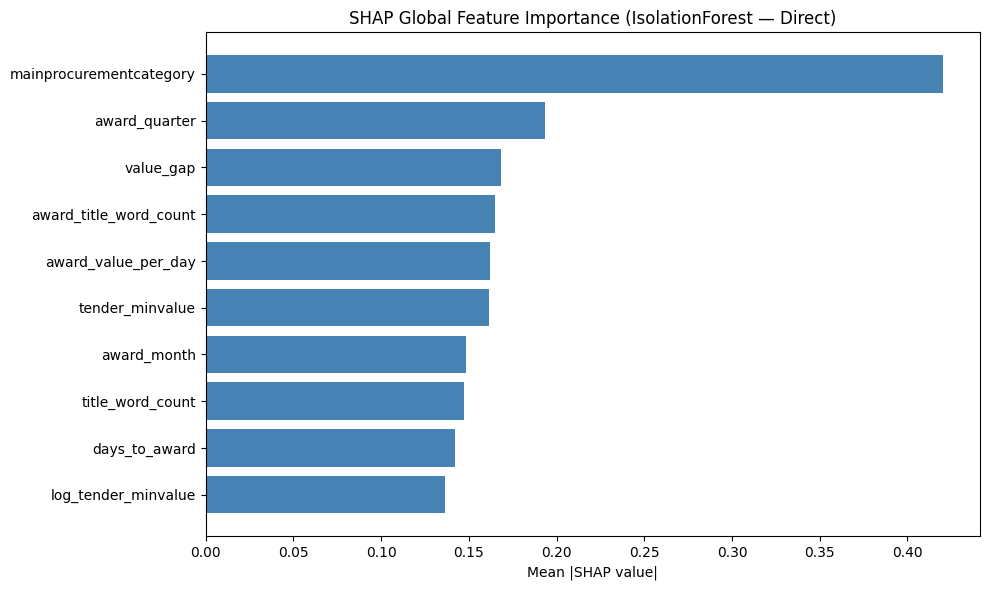

Plot saved.


In [96]:
print_section("SHAP GLOBAL EXPLAINABILITY")
print("Menghitung SHAP values pada test set...")

# Nama fitur setelah preprocessing
feature_names = preprocessor.get_feature_names_out()
feature_names_clean = [
    f.replace("num__", "").replace("cat__mainprocurementcategory_", "cat_")
    for f in feature_names
]

# TreeExplainer langsung pada IsolationForest (tanpa surrogate)
explainer_shap = shap.TreeExplainer(model)
shap_values_test = explainer_shap.shap_values(X_test)

print(f"SHAP values shape: {shap_values_test.shape}")

# Global importance = mean absolute SHAP per fitur
shap_importance = pd.DataFrame({
    "feature"        : feature_names_clean,
    "mean_abs_shap"  : np.abs(shap_values_test).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

# Gabungkan categorical yang berasal dari OHE
shap_importance["raw_feature"] = shap_importance["feature"].apply(
    lambda x: "mainprocurementcategory" if x.startswith("cat_") else x
)
shap_global = (
    shap_importance.groupby("raw_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)

shap_global.to_csv(artifact_dir / "shap_global_importance.csv", index=False)
print("\nTop-10 Global SHAP Importance:")
print(shap_global.head(10).to_string(index=False))

# Plot
top10 = shap_global.head(10).sort_values("mean_abs_shap")
plt.figure(figsize=(10, 6))
plt.barh(top10["raw_feature"], top10["mean_abs_shap"], color="steelblue")
plt.title("SHAP Global Feature Importance (IsolationForest — Direct)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig(artifact_dir / "shap_global_importance.png", dpi=150)
plt.show()
print("Plot saved.")

## 5. SHAP Local Explanation per Prediksi 


In [ ]:
import pandas as pd
import numpy as np

# Ambil base value dari explainer
base_value = explainer_shap.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

# Simpan SHAP values per row untuk test set
shap_df = pd.DataFrame(shap_values_test, columns=feature_names_clean)

# === OPTIMASI 1: Variabel statis di luar ===
DAFTAR_HARI = ["Senin", "Selasa", "Rabu", "Kamis", "Jumat", "Sabtu", "Minggu"]
KAMUS_INDO = {
    "tender_value": "Nilai tender",
    "award_id": "ID Kontrak",
    "buyer_name": "Nama Instansi",
    "buyer_id": "ID Instansi"
}

def format_rupiah(angka):
    """Mengubah format angka ke format Rupiah (titik)"""
    if pd.isna(angka):
        return "N/A"
    return f"Rp {angka:,.0f}".replace(',', '.')

def aggregate_shap_to_raw(row_shap, feature_names_clean):
    """Aggregate SHAP values ke raw feature level."""
    aggregated = {}
    for feat, val in zip(feature_names_clean, row_shap):
        raw = "mainprocurementcategory" if feat.startswith("cat_") else feat
        aggregated[raw] = aggregated.get(raw, 0.0) + val
    return aggregated

# === OPTIMASI 2: Logic Handlers (Memisahkan logika ke fungsi-fungsi kecil) ===
def handle_log(feat, num_val, is_aneh):
    try:
        asli_rupiah = np.exp(num_val) if num_val < 100 else num_val
        val_str = format_rupiah(asli_rupiah)
    except:
        val_str = str(round(num_val, 2))

    nama_konsep = {
        "log_tender_value": "Nilai awal tender",
        "log_award_value": "Nilai kontrak akhir",
        "log_tender_minvalue": "Batas minimum tender",
        "log_value_gap": "Selisih penghematan"
    }.get(feat, feat.replace("log_", "").replace("_", " ").title())

    if is_aneh:
        return f"Besaran {nama_konsep} (estimasi {val_str}) tercatat tidak wajar dan memiliki risiko deviasi anggaran."
    return f"Besaran {nama_konsep} (estimasi {val_str}) terpantau wajar dan sesuai dengan profil historis."

def handle_days_to_award(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Proses lelang selesai dalam {int(num_val)} hari, durasi ini tergolong tidak lazim (terlalu cepat/lama)."
    return f"Proses lelang memakan waktu {int(num_val)} hari, yang merupakan durasi wajar untuk pengadaan sejenis."

def handle_budget_ratio(num_val, is_aneh, **kwargs):
    persen = num_val * 100
    if is_aneh:
        return f"Tingkat serapan anggaran mencapai {persen:.1f}%, angka ini mencurigakan (indikasi mark-up atau inefisiensi)."
    return f"Tingkat serapan anggaran sebesar {persen:.1f}% dinilai masih berada dalam batas toleransi keuangan."

def handle_value_gap(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Terdapat selisih tidak proporsional antara nilai tender awal dan kontrak akhir sebesar {format_rupiah(num_val)}."
    return f"Penghematan anggaran (selisih tender dan kontrak) sebesar {format_rupiah(num_val)} terdeteksi normal."

def handle_award_value(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Nilai kontrak yang disetujui ({format_rupiah(num_val)}) berada di luar rentang kewajaran profil proyek ini."
    return f"Nominal kontrak akhir sebesar {format_rupiah(num_val)} sesuai dengan standar harga pasar."

def handle_tender_minvalue(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Nilai batas minimum tender sebesar {format_rupiah(num_val)} memiliki risiko deviasi anggaran yang tinggi."
    return f"Batas minimum tender ({format_rupiah(num_val)}) berada pada rentang aman."

def handle_award_value_per_day(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Rata-rata pengeluaran anggaran mencapai {format_rupiah(num_val)} per hari, nominal ini dinilai tidak proporsional dengan waktu pelaksanaan proyek."
    return f"Estimasi pengeluaran harian sebesar {format_rupiah(num_val)} per hari masih tergolong wajar dan masuk akal."

def handle_award_title_word_count(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Judul dokumen kontrak menggunakan {int(num_val)} kata, format penamaan ini melenceng dari kebiasaan administrasi."
    return f"Judul dokumen kontrak terdiri dari {int(num_val)} kata, format penamaan dokumen tergolong standar."

def handle_title_word_count(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Judul awal dokumen tender menggunakan {int(num_val)} kata, format redaksi ini mengindikasikan adanya kejanggalan administratif."
    return f"Judul awal dokumen tender terdiri dari {int(num_val)} kata, format penamaan sesuai dengan standar penulisan."

def handle_award_weekday(num_val, is_aneh, **kwargs):
    idx_hari = int(num_val) if 0 <= int(num_val) <= 6 else 0
    nama_hari = DAFTAR_HARI[idx_hari]
    if is_aneh:
        if idx_hari >= 5: 
            return f"Penetapan pemenang dilakukan pada hari libur ({nama_hari}), indikasi kuat ketidakwajaran proses."
        return f"Meski disahkan pada hari kerja ({nama_hari}), tercatat ada anomali waktu pada sistem saat penetapan."
    return f"Penetapan pemenang dilakukan pada hari kerja ({nama_hari}), sesuai jam operasional instansi."

def handle_buyer_name_encoded(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Terdeteksi riwayat pengadaan yang kurang lazim dari instansi penyelenggara ini (Kode Sistem: {int(num_val)})."
    return f"Instansi penyelenggara (Kode Sistem: {int(num_val)}) memiliki rekam jejak pengadaan yang wajar."

def handle_maincategory(raw_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Karakteristik data tidak cocok dengan kategori proyek '{raw_val}'."
    return f"Kategori proyek '{raw_val}' sesuai dengan peruntukannya."

def handle_suppliers(num_val, is_aneh, **kwargs):
    if is_aneh:
        return f"Jumlah peserta tender ({int(num_val)} pihak) sangat minim, indikasi kurangnya kompetisi yang sehat."
    return f"Jumlah peserta tender ({int(num_val)} pihak) menunjukkan tingkat kompetisi lelang yang memadai."

def handle_fallback(feat, num_val, raw_val, is_aneh):
    nama_fitur_bersih = KAMUS_INDO.get(feat, feat.replace("_", " ").title())
    if num_val is not None:
        val_str = format_rupiah(num_val) if num_val > 1000 else str(round(num_val, 2))
    else:
        val_str = str(raw_val)
        
    if is_aneh:
        return f"Terdapat deviasi evaluasi pada metrik '{nama_fitur_bersih}' (angka referensi: {val_str}) yang membutuhkan tinjauan lanjutan."
    return f"Metrik pengadaan '{nama_fitur_bersih}' (angka referensi: {val_str}) terpantau wajar dan sesuai regulasi."

# === OPTIMASI 3: Dictionary Mapping (Menghancurkan Brutal IF-ELSE) ===
# Memetakan nama fitur ke fungsi yang tepat (O(1) Lookup Time)
FEATURE_DISPATCH = {
    "days_to_award": handle_days_to_award,
    "budget_utilization_ratio": handle_budget_ratio,
    "value_gap": handle_value_gap,
    "award_value": handle_award_value,
    "tender_minvalue": handle_tender_minvalue,
    "award_value_per_day": handle_award_value_per_day,
    "award_title_word_count": handle_award_title_word_count,
    "title_word_count": handle_title_word_count,
    "award_weekday": handle_award_weekday,
    "buyer_name_encoded": handle_buyer_name_encoded,
    "mainprocurementcategory": handle_maincategory,
    "supplay_tender": handle_suppliers,
    "supply_tender": handle_suppliers,
    "supplier_count": handle_suppliers,
    "tender_suppliers": handle_suppliers
}

def generate_natural_reason(feat, raw_val, shap_val):
    """Fungsi utama yang sangat cepat dengan Dictionary Mapping."""
    try:
        num_val = float(raw_val)
    except (ValueError, TypeError):
        num_val = None

    is_aneh = shap_val < 0 

    # Cek Logaritma dulu
    if feat.startswith("log_") and num_val is not None:
        return handle_log(feat, num_val, is_aneh)

    # Dictionary Lookup (Sangat cepat, pengganti IF-ELSE)
    handler_func = FEATURE_DISPATCH.get(feat)
    
    if handler_func:
        return handler_func(num_val=num_val, raw_val=raw_val, is_aneh=is_aneh)
    else:
        return handle_fallback(feat, num_val, raw_val, is_aneh)

def explain_with_shap(row_idx, row_data, row_shap, feature_names_clean, base_value):
    is_anomaly  = row_data["prediction_label"] == "anomaly"
    label_text  = "ANOMALI" if is_anomaly else "NORMAL"

    agg = aggregate_shap_to_raw(row_shap, feature_names_clean)
    
    if is_anomaly:
        sorted_features = sorted(agg.items(), key=lambda x: x[1])[:3]  
    else:
        sorted_features = sorted(agg.items(), key=lambda x: x[1], reverse=True)[:3] 

    result = {}
    summary_lines = []

    for idx, (feat, shap_val) in enumerate(sorted_features, start=1):
        direction_en = "positive" if shap_val > 0 else "negative"
        raw_val = row_data[feat] if feat in row_data.index else "N/A"
        
        reason = generate_natural_reason(feat, raw_val, shap_val)

        result[f"top_{idx}_feature"] = feat
        result[f"top_{idx}_shap"]    = round(float(shap_val), 6)
        result[f"top_{idx}_impact"]  = direction_en
        result[f"top_{idx}_reason"]  = reason
        
        summary_lines.append(f"Alasan {idx}: {reason}")

    if is_anomaly:
        intro = "Sistem mendeteksi dokumen ini MENCURIGAKAN berdasarkan poin-poin berikut:"
    else:
        intro = "Status transaksi dinilai WAJAR DAN AMAN berdasarkan poin-poin berikut:"

    result["human_readable_explanation"] = f"[{label_text}] {intro}\n" + "\n".join(summary_lines)
    return result 

# === BLOK EKSEKUSI ===
print("Generating smart explanations for test set...")
test_data_reset = test_data.reset_index(drop=True)

explanation_rows = [
    explain_with_shap(i, test_data_reset.iloc[i], shap_values_test[i], feature_names_clean, base_value)
    for i in range(len(test_data_reset))
]
test_output = pd.concat([test_data_reset, pd.DataFrame(explanation_rows)], axis=1)

print("Generating smart explanations for train set...")
shap_values_train = explainer_shap.shap_values(X_train)
train_data_reset  = train_data.reset_index(drop=True)

train_explanation_rows = [
    explain_with_shap(i, train_data_reset.iloc[i], shap_values_train[i], feature_names_clean, base_value)
    for i in range(len(train_data_reset))
]
train_output = pd.concat([train_data_reset, pd.DataFrame(train_explanation_rows)], axis=1)

# Simpan Artefak
train_output.to_csv(artifact_dir / "train_predictions_with_explanations.csv", index=False)
test_output.to_csv(artifact_dir / "test_predictions_with_explanations.csv", index=False)
test_output.loc[test_output["prediction_label"] == "anomaly"] \
    .sort_values("anomaly_score", ascending=False) \
    .to_csv(artifact_dir / "test_anomalies_only.csv", index=False)

print("\n--- PROSES SELESAI ---")
print(f"Train explanations saved : {len(train_output)} rows")
print(f"Test explanations saved  : {len(test_output)} rows")

Generating smart explanations for test set...
Generating smart explanations for train set...

--- PROSES SELESAI ---
Train explanations saved : 7376 rows
Test explanations saved  : 1302 rows


## 6. SHAP Baseline untuk Inference (disimpan ke JSON)

In [98]:
# Simpan SHAP explainer agar bisa dimuat ulang di inference.ipynb
joblib.dump(explainer_shap, artifact_dir / "shap_explainer.joblib")

# Simpan feature names setelah preprocessing (dibutuhkan saat inference)
explanation_meta = {
    "explainability_method"     : "SHAP TreeExplainer — direct on IsolationForest",
    "feature_names_preprocessed": list(feature_names_clean),
    "explanation_numeric_features": explanation_numeric_features,
    "categorical_features"      : model_categorical_features,
    "shap_note"                 : (
        "SHAP values diinterpretasikan sebagai kontribusi fitur terhadap anomaly score. "
        "Nilai positif = mendorong ke arah anomaly, negatif = mendorong ke arah normal."
    ),
}
(artifact_dir / "explanation_meta.json").write_text(
    json.dumps(to_builtin(explanation_meta), indent=2), encoding="utf-8"
)

print("Saved:")
print(f"  - shap_explainer.joblib")
print(f"  - explanation_meta.json")

Saved:
  - shap_explainer.joblib
  - explanation_meta.json


## 7. Reference Thresholds & Proxy Evaluation

In [99]:
category_reference = train_data.groupby("mainprocurementcategory").agg(
    award_value_p99=("award_value", lambda s: float(s.quantile(0.99))),
    days_to_award_p95=("days_to_award", lambda s: float(s.quantile(0.95))),
    budget_ratio_p05=("budget_utilization_ratio", lambda s: float(s.quantile(0.05))),
    budget_ratio_p95=("budget_utilization_ratio", lambda s: float(s.quantile(0.95))),
).reset_index()

global_reference = {
    "award_value_p99"    : float(train_data["award_value"].quantile(0.99)),
    "days_to_award_p95"  : float(train_data["days_to_award"].quantile(0.95)),
    "budget_ratio_p05"   : float(train_data["budget_utilization_ratio"].quantile(0.05)),
    "budget_ratio_p95"   : float(train_data["budget_utilization_ratio"].quantile(0.95)),
}

reference_thresholds = {
    "category_reference" : category_reference.to_dict(orient="records"),
    "global_reference"   : global_reference,
    "proxy_rule_columns" : [
        "rule_over_budget", "rule_same_day_award",
        "rule_extreme_award_value", "rule_long_award_duration",
        "rule_extreme_budget_ratio",
    ],
}
(artifact_dir / "reference_thresholds.json").write_text(
    json.dumps(to_builtin(reference_thresholds), indent=2), encoding="utf-8"
)

# Proxy evaluation
test_eval = test_output.merge(category_reference, on="mainprocurementcategory", how="left")
for col, fallback_value in global_reference.items():
    test_eval[col] = test_eval[col].fillna(fallback_value)

test_eval["rule_over_budget"]          = test_eval["budget_utilization_ratio"] > 1.0
test_eval["rule_same_day_award"]       = test_eval["days_to_award"] == 0
test_eval["rule_extreme_award_value"]  = test_eval["award_value"] >= test_eval["award_value_p99"]
test_eval["rule_long_award_duration"]  = test_eval["days_to_award"] >= test_eval["days_to_award_p95"]
test_eval["rule_extreme_budget_ratio"] = (
    (test_eval["budget_utilization_ratio"] <= test_eval["budget_ratio_p05"])
    | (test_eval["budget_utilization_ratio"] >= test_eval["budget_ratio_p95"])
)

proxy_rule_columns = reference_thresholds["proxy_rule_columns"]
test_eval["proxy_rule_count"]  = test_eval[proxy_rule_columns].sum(axis=1)
test_eval["proxy_anomaly_flag"] = (
    (test_eval["proxy_rule_count"] >= 2)
    | test_eval["rule_over_budget"]
    | test_eval["rule_same_day_award"]
).astype(int)

proxy_y_true  = test_eval["proxy_anomaly_flag"].astype(int)
proxy_y_pred  = test_eval["anomaly_flag"].astype(int)
proxy_precision = precision_score(proxy_y_true, proxy_y_pred, zero_division=0)
proxy_recall    = recall_score(proxy_y_true, proxy_y_pred, zero_division=0)
proxy_f1        = f1_score(proxy_y_true, proxy_y_pred, zero_division=0)

top_n = max(1, int(round(len(test_eval) * contamination)))
top_score_slice    = test_eval.sort_values("anomaly_score", ascending=False).head(top_n)
precision_at_top_n = float(top_score_slice["proxy_anomaly_flag"].mean())

test_eval.to_csv(artifact_dir / "test_predictions_with_proxy_evaluation.csv", index=False)

print_section("RETROSPECTIVE PROXY EVALUATION")
print(f"Proxy precision       : {proxy_precision:.2%}")
print(f"Proxy recall          : {proxy_recall:.2%}")
print(f"Proxy F1              : {proxy_f1:.2%}")
print(f"Precision@Top{top_n}    : {precision_at_top_n:.2%}")

RETROSPECTIVE PROXY EVALUATION
Proxy precision       : 22.22%
Proxy recall          : 53.33%
Proxy F1              : 31.37%
Precision@Top39    : 20.51%


## 8. Demo Cases untuk inference.ipynb

In [100]:
normal_demo = test_output.loc[test_output["prediction_label"] == "normal"].copy()
normal_demo["demo_distance"] = (normal_demo["anomaly_score"] - normal_demo["anomaly_score"].median()).abs()
normal_demo = normal_demo.sort_values("demo_distance").head(1).drop(columns=["demo_distance"])

borderline_demo = test_output.loc[test_output["prediction_label"] == "normal"].copy()
borderline_demo["demo_distance"] = (borderline_demo["anomaly_score"] - threshold).abs()
borderline_demo = borderline_demo.sort_values("demo_distance").head(1).drop(columns=["demo_distance"])

anomaly_demo = test_output.loc[test_output["prediction_label"] == "anomaly"] \
    .sort_values("anomaly_score", ascending=False).head(1).copy()

demo_cases = pd.concat([normal_demo, borderline_demo, anomaly_demo], ignore_index=True)
demo_cases["demo_case_label"] = ["normal_demo", "borderline_demo", "anomaly_demo"]

demo_input_cols = [
    "demo_case_label", "date", "buyer_name", "tender_title",
    "mainprocurementcategory", "tender_minvalue", "tender_status",
    "award_title", "award_date", "award_value", "award_supplier",
    "days_to_award", "budget_utilization_ratio",
]
demo_output_cols = demo_input_cols + [
    "anomaly_score", "severity_band", "prediction_label",
    "top_1_feature", "top_1_shap", "top_1_impact",
    "top_2_feature", "top_2_shap", "top_2_impact",
    "top_3_feature", "top_3_shap", "top_3_impact",
    "human_readable_explanation",
]

demo_cases[demo_input_cols].to_csv(artifact_dir / "demo_input_cases.csv", index=False)
demo_cases[demo_output_cols].to_csv(artifact_dir / "demo_expected_outputs.csv", index=False)

print("Demo cases saved.")
display(demo_cases[["demo_case_label", "anomaly_score", "prediction_label",
                     "top_1_feature", "top_1_shap", "human_readable_explanation"]])

Demo cases saved.


,demo_case_label,anomaly_score,prediction_label,top_1_feature,top_1_shap,human_readable_explanation
0,normal_demo,0.432089,normal,award_title_word_count,0.180758,[NORMAL] Status transaksi dinilai WAJAR DAN AM...
1,borderline_demo,0.587034,normal,mainprocurementcategory,0.388464,[NORMAL] Status transaksi dinilai WAJAR DAN AM...
2,anomaly_demo,0.767747,anomaly,tender_minvalue,-1.334543,[ANOMALI] Sistem mendeteksi dokumen ini MENCUR...


## 9. Final Summary

In [101]:
print_section("FINAL SUMMARY")
print("Pipeline type         : Post-award anomaly detection")
print("Model                 : IsolationForest (sklearn)")
print("Explainability        : SHAP TreeExplainer (langsung pada IsolationForest)")
print("Leakage guard         : Time-based split sebelum preprocessing")
print("Evaluation            : Retrospective proxy-label validation")
print(f"Training period end   : {train_max_date.date()}")
print(f"Testing period start  : {test_min_date.date()}")
print(f"Train anomaly rate    : {train_data['anomaly_flag'].mean():.2%}")
print(f"Test anomaly rate     : {test_data['anomaly_flag'].mean():.2%}")
print("\nTest severity bands:")
print(test_data['severity_band'].value_counts().to_string())
print(f"\nProxy precision       : {proxy_precision:.2%}")
print(f"Proxy recall          : {proxy_recall:.2%}")
print(f"Proxy F1              : {proxy_f1:.2%}")
print(f"Precision@Top{top_n}    : {precision_at_top_n:.2%}")
print(f"Artifacts directory   : {artifact_dir.resolve()}")
print("\nConstraint compliance:")
print("  C1 Explainability  : SHAP TreeExplainer ✓")
print("  C2 Human-readable  : top-3 fitur + arah + SHAP value ✓")
print("  C3 Anti-Black Box  : SHAP langsung pada IsolationForest (bukan surrogate) ✓")
print("  C4 No Leakage      : time-based split sebelum preprocessing ✓")
print("  C5 Offline         : sklearn + shap, tidak ada cloud API ✓")
print("\nKey exported files:")
for f in [
    "isolation_forest.joblib", "preprocessor.joblib",
    "shap_explainer.joblib", "model_config.json",
    "explanation_meta.json", "reference_thresholds.json",
    "shap_global_importance.csv", "shap_global_importance.png",
    "train_post_award_split.csv", "test_post_award_split.csv",
    "train_predictions_with_explanations.csv",
    "test_predictions_with_explanations.csv",
    "test_anomalies_only.csv",
    "test_predictions_with_proxy_evaluation.csv",
    "demo_input_cases.csv", "demo_expected_outputs.csv",
]:
    print(f"  - {f}")

FINAL SUMMARY
Pipeline type         : Post-award anomaly detection
Model                 : IsolationForest (sklearn)
Explainability        : SHAP TreeExplainer (langsung pada IsolationForest)
Leakage guard         : Time-based split sebelum preprocessing
Evaluation            : Retrospective proxy-label validation
Training period end   : 2022-03-23
Testing period start  : 2022-03-24
Train anomaly rate    : 3.01%
Test anomaly rate     : 2.76%

Test severity bands:
severity_band
low       951
medium    315
high       36

Proxy precision       : 22.22%
Proxy recall          : 53.33%
Proxy F1              : 31.37%
Precision@Top39    : 20.51%
Artifacts directory   : D:\Documents\lomba\cortia\notebooks\artifacts\post_award_anomaly

Constraint compliance:
  C1 Explainability  : SHAP TreeExplainer ✓
  C2 Human-readable  : top-3 fitur + arah + SHAP value ✓
  C3 Anti-Black Box  : SHAP langsung pada IsolationForest (bukan surrogate) ✓
  C4 No Leakage      : time-based split sebelum preprocessing 